# Project Dataloader Demonstration
This project uses a custom DataLoader to load all images corresponding with a specific patient. Accompanying the images are their associated image type, cancer label, and demographic information.

In [2]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import pandas as pd
import matplotlib.pyplot as plt
from midas.data.dataloader import MIDASDataset
from midas.data.augmentation import standard_transform
from torch.utils.data import DataLoader

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


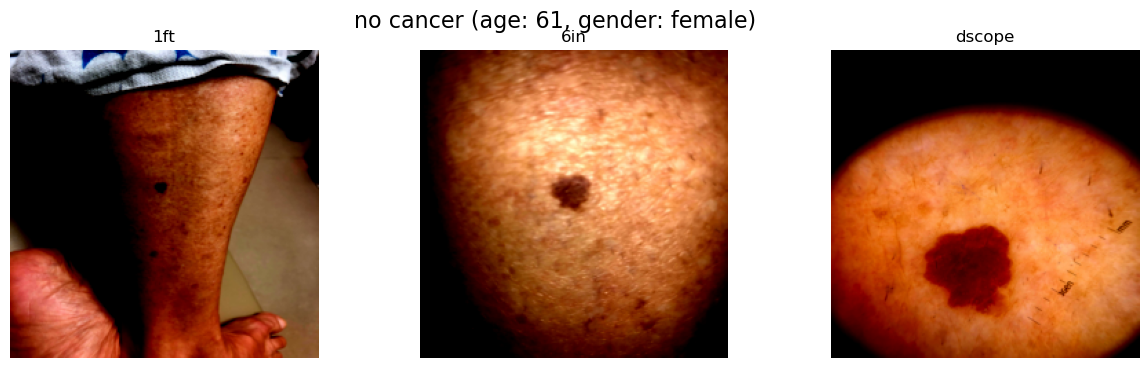

In [35]:
dataset = MIDASDataset(data_dir="../sample_data/images", data="../sample_data/midas_sample.csv", transform=standard_transform)
loader = DataLoader(dataset, batch_size=1, shuffle=True)

images, image_types, metadata, labels = next(iter(loader))
patient_images = images[0] 
patient_img_types = image_types[0]
patient_metadata = metadata[0]

type_map = {0: "dscope", 1: "6in", 2: "1ft", 3: "n/a - virtual"}
gender_map = {0: "female", 1: "male"}
class_map = {0: "no cancer", 1: "cancer"}

plt.figure(figsize=(15, 4))
for i in range(patient_images.shape[0]):
    image = patient_images[i].permute(1, 2, 0)
    plt.subplot(1, patient_images.shape[0], i + 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(type_map[int(patient_img_types[i])])
plt.suptitle(f"{class_map[int(labels)]} (age: {int(patient_metadata[0])}, gender: {gender_map[int(patient_metadata[1])]})", fontsize=16)
plt.show()